In [1]:

PREPROCESSED_DIR = "/kaggle/input/datasets/iftekharuddin27/preprocessed-datasets"
MODELS_DIR       = "/kaggle/input/datasets/iftekharuddin27/transformer-models"
OUTPUT_DIR       = "/kaggle/working/"

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, f1_score)
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          Trainer, TrainingArguments)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
CLASS_NAMES = {0: 'Non-hateful', 1: 'Hateful', 2: 'Sarcastic'}
print(f"Device: {device}")

Device: cuda


In [2]:
# ============================================================
# CELL 2 — Load test data
# ============================================================
en_test = pd.read_csv(f"{PREPROCESSED_DIR}/en_test.csv")
bn_test = pd.read_csv(f"{PREPROCESSED_DIR}/bn_test.csv")

en_test['text_clean'] = en_test['text_clean'].fillna('')
bn_test['text_clean'] = bn_test['text_clean'].fillna('')

y_en_test = en_test['class'].values
y_bn_test = bn_test['label'].values

print(f"English test : {len(en_test):,} rows")
print(f"Bangla  test : {len(bn_test):,} rows")

English test : 10,432 rows
Bangla  test : 8,377 rows


In [3]:
# ============================================================
# CELL 3 — Evaluation helper
# ============================================================
all_test_results = []

def evaluate_model(model_name, y_true, y_pred, dataset_name):
    acc     = accuracy_score(y_true, y_pred)
    f1_mac  = f1_score(y_true, y_pred, average='macro')

    print(f"\n{'='*60}")
    print(f"{model_name} [TEST] — {dataset_name}")
    print(f"{'='*60}")
    print(f"Accuracy : {acc:.4f}")
    print(f"Macro F1 : {f1_mac:.4f}")
    print(classification_report(y_true, y_pred,
                                target_names=list(CLASS_NAMES.values())))

    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES.values(),
                yticklabels=CLASS_NAMES.values(), ax=ax)
    ax.set_title(f'{model_name} [TEST] — {dataset_name}')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}test_cm_{model_name}_{dataset_name}.png", dpi=100)
    plt.show()

    all_test_results.append({
        'model': model_name, 'dataset': dataset_name,
        'accuracy': round(acc, 4), 'macro_f1': round(f1_mac, 4)
    })
    return acc, f1_mac

In [4]:
# ============================================================
# CELL 4 — Core test function (load → predict → evaluate)
# ============================================================
class TransformerDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels    = labels
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

def test_transformer(model_path, test_texts, test_labels, display_name, dataset_name):
    print(f"\nLoading {display_name} from:\n  {model_path}")

    tokenizer = AutoTokenizer.from_pretrained(model_path)
    model     = AutoModelForSequenceClassification.from_pretrained(model_path)
    model     = model.to(device)
    model.eval()

    encodings    = tokenizer(list(test_texts), truncation=True, padding=True,
                             max_length=128, return_tensors='pt')
    test_dataset = TransformerDataset(encodings, list(test_labels))

    args = TrainingArguments(
        output_dir=f'{OUTPUT_DIR}tmp_eval',
        per_device_eval_batch_size=64,
        report_to='none',
        fp16=torch.cuda.is_available(),
    )
    trainer = Trainer(model=model, args=args)

    preds_out = trainer.predict(test_dataset)
    preds     = preds_out.predictions.argmax(axis=1)
    probs     = torch.nn.functional.softmax(
                    torch.tensor(preds_out.predictions), dim=1).numpy()

    evaluate_model(display_name, test_labels, preds, dataset_name)

    # Save for Phase 4 & 5 (sample selection + error analysis)
    np.save(f"{OUTPUT_DIR}test_preds_{display_name}_{dataset_name}.npy", preds)
    np.save(f"{OUTPUT_DIR}test_probs_{display_name}_{dataset_name}.npy", probs)
    print(f"Predictions saved to /kaggle/working/")

    del model, trainer
    torch.cuda.empty_cache()
    return preds, probs


Loading BERT from:
  /kaggle/input/datasets/iftekharuddin27/transformer-models/BERT_English


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


BERT [TEST] — English
Accuracy : 0.9033
Macro F1 : 0.9029
              precision    recall  f1-score   support

 Non-hateful       0.88      0.85      0.87      3470
     Hateful       0.91      0.94      0.92      3486
   Sarcastic       0.92      0.92      0.92      3476

    accuracy                           0.90     10432
   macro avg       0.90      0.90      0.90     10432
weighted avg       0.90      0.90      0.90     10432



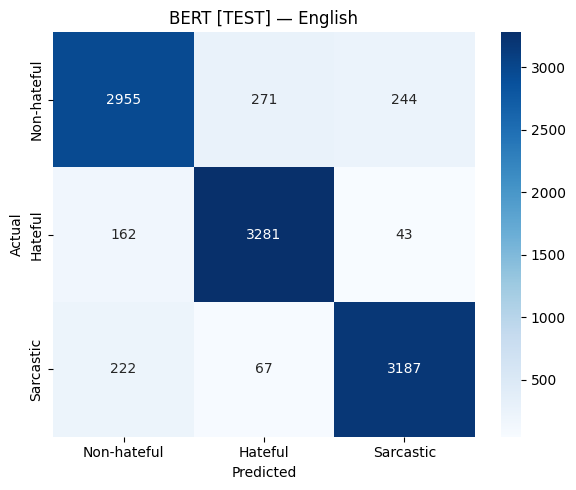

Predictions saved to /kaggle/working/


In [5]:
# ============================================================
# CELL 5 — English: BERT
# ============================================================
bert_preds, bert_probs = test_transformer(
    f"{MODELS_DIR}/BERT_English",
    en_test['text_clean'].values, y_en_test,
    "BERT", "English"
)


Loading DistilBERT from:
  /kaggle/input/datasets/iftekharuddin27/transformer-models/DistilBERT_English


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]


DistilBERT [TEST] — English
Accuracy : 0.8937
Macro F1 : 0.8937
              precision    recall  f1-score   support

 Non-hateful       0.86      0.86      0.86      3470
     Hateful       0.92      0.91      0.92      3486
   Sarcastic       0.90      0.90      0.90      3476

    accuracy                           0.89     10432
   macro avg       0.89      0.89      0.89     10432
weighted avg       0.89      0.89      0.89     10432



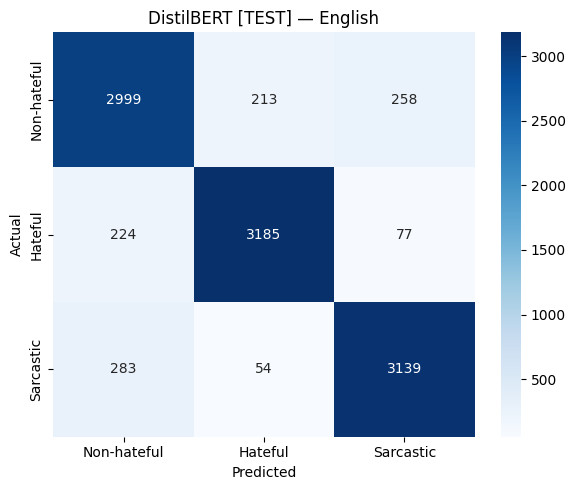

Predictions saved to /kaggle/working/


In [6]:
# ============================================================
# CELL 6 — English: DistilBERT
# ============================================================
distilbert_preds, distilbert_probs = test_transformer(
    f"{MODELS_DIR}/DistilBERT_English",
    en_test['text_clean'].values, y_en_test,
    "DistilBERT", "English"
)


Loading BanglaBERT from:
  /kaggle/input/datasets/iftekharuddin27/transformer-models/BanglaBERT


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


BanglaBERT [TEST] — Bangla
Accuracy : 0.8316
Macro F1 : 0.8200
              precision    recall  f1-score   support

 Non-hateful       0.88      0.79      0.83      4140
     Hateful       0.85      0.94      0.89      2560
   Sarcastic       0.71      0.77      0.74      1677

    accuracy                           0.83      8377
   macro avg       0.81      0.83      0.82      8377
weighted avg       0.84      0.83      0.83      8377



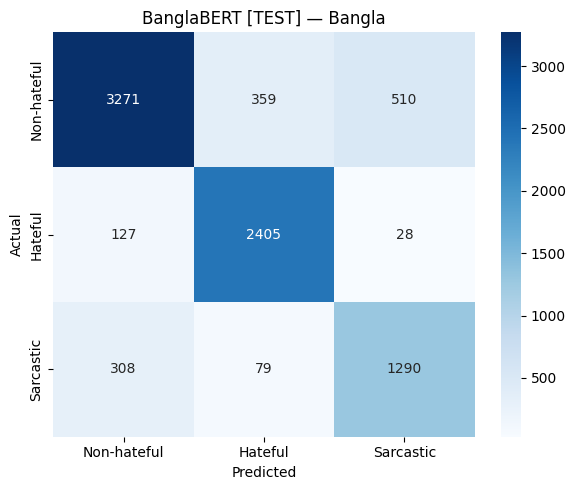

Predictions saved to /kaggle/working/


In [7]:
# ============================================================
# CELL 7 — Bangla: BanglaBERT
# ============================================================
banglabert_preds, banglabert_probs = test_transformer(
    f"{MODELS_DIR}/BanglaBERT",
    bn_test['text_clean'].values, y_bn_test,
    "BanglaBERT", "Bangla"
)


Loading mBERT from:
  /kaggle/input/datasets/iftekharuddin27/transformer-models/mBERT


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


mBERT [TEST] — Bangla
Accuracy : 0.7796
Macro F1 : 0.7739
              precision    recall  f1-score   support

 Non-hateful       0.89      0.67      0.76      4140
     Hateful       0.85      0.93      0.88      2560
   Sarcastic       0.56      0.84      0.67      1677

    accuracy                           0.78      8377
   macro avg       0.77      0.81      0.77      8377
weighted avg       0.81      0.78      0.78      8377



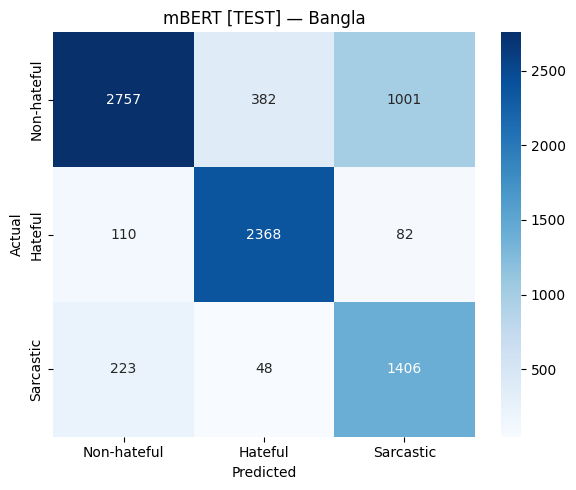

Predictions saved to /kaggle/working/


In [8]:
# ============================================================
# CELL 8 — Bangla: mBERT
# ============================================================
mbert_preds, mbert_probs = test_transformer(
    f"{MODELS_DIR}/mBERT",
    bn_test['text_clean'].values, y_bn_test,
    "mBERT", "Bangla"
)

In [9]:
# ============================================================
# CELL 9 — Summary table of all test results
# ============================================================
import pandas as pd
results_df = pd.DataFrame(all_test_results)
print("\n" + "="*60)
print("FINAL TEST SET RESULTS SUMMARY")
print("="*60)
print(results_df.to_string(index=False))
results_df.to_csv(f"{OUTPUT_DIR}test_results_summary.csv", index=False)
print("\nSaved to test_results_summary.csv")


FINAL TEST SET RESULTS SUMMARY
     model dataset  accuracy  macro_f1
      BERT English    0.9033    0.9029
DistilBERT English    0.8937    0.8937
BanglaBERT  Bangla    0.8316    0.8200
     mBERT  Bangla    0.7796    0.7739

Saved to test_results_summary.csv
